In [1]:
#loading python classes and packages
from ultralytics import YOLO
import mediapipe as mp
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, RepeatVector, Bidirectional, LSTM, GRU
from tensorflow.keras.layers import Convolution2D
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import copy
import itertools
import warnings
warnings.filterwarnings("ignore")
print("All packages loaded")

All packages loaded


In [2]:
#yolo confidence threshold to detect hand signs
CONFIDENCE_THRESHOLD = 0.50
GREEN = (0, 255, 0)
yolo_model = YOLO("model/best.pt")
print("Yolo Model Loaded")

Yolo Model Loaded


In [3]:
#function to detect signs using YOLO11
def detectSign(frame):
    global yolo_model
    sign_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
    detections = yolo_model(frame)[0]
    label = None
    # loop over the detections
    for data in detections.boxes.data.tolist():
        print(data)
        # extract the confidence (i.e., probability) associated with the detection
        confidence = data[4]
        cls_id = data[5]
        # filter out weak detections by ensuring the 
        # confidence is greater than the minimum confidence
        if float(confidence) >= CONFIDENCE_THRESHOLD:
            xmin, ymin, xmax, ymax = int(data[0]), int(data[1]), int(data[2]), int(data[3])
            label = sign_labels[int(cls_id)]
            cv2.rectangle(frame, (xmin, ymin) , (xmax, ymax), GREEN, 2)
            cv2.putText(frame, sign_labels[int(cls_id)], (xmin, ymin-10),  cv2.FONT_HERSHEY_SIMPLEX,0.7, (255, 0, 0), 2)            
    return frame, label

In [4]:
#global variables definition to detect hand signs
X = []
Y = []
filename = "Dataset"
labels = []
min_detection_confidence = 0.7
min_tracking_confidence = 0.5
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=min_detection_confidence, min_tracking_confidence=min_tracking_confidence)
drawingModule = mp.solutions.drawing_utils
min_detection_confidence = 0.7
min_tracking_confidence = 0.5

In [5]:
#function to detect hand features
def calc_bounding_rect(image, landmarks):
    image_width, image_height = image.shape[1], image.shape[0]
    landmark_array = np.empty((0, 2), int)
    for _, landmark in enumerate(landmarks.landmark):
        landmark_x = min(int(landmark.x * image_width), image_width - 1)
        landmark_y = min(int(landmark.y * image_height), image_height - 1)
        landmark_point = [np.array((landmark_x, landmark_y))]
        landmark_array = np.append(landmark_array, landmark_point, axis=0)
    x, y, w, h = cv2.boundingRect(landmark_array)
    return [x, y, x + w, y + h]


def calc_landmark_list(image, landmarks):
    image_width, image_height = image.shape[1], image.shape[0]
    landmark_point = []
    for _, landmark in enumerate(landmarks.landmark):
        landmark_x = min(int(landmark.x * image_width), image_width - 1)
        landmark_y = min(int(landmark.y * image_height), image_height - 1)
        landmark_point.append([landmark_x, landmark_y])
    return landmark_point


def pre_process_landmark(landmark_list):
    temp_landmark_list = copy.deepcopy(landmark_list)
    base_x, base_y = 0, 0
    for index, landmark_point in enumerate(temp_landmark_list):
        if index == 0:
            base_x, base_y = landmark_point[0], landmark_point[1]
        temp_landmark_list[index][0] = temp_landmark_list[index][0] - base_x
        temp_landmark_list[index][1] = temp_landmark_list[index][1] - base_y
    temp_landmark_list = list(itertools.chain.from_iterable(temp_landmark_list))
    max_value = max(list(map(abs, temp_landmark_list)))
    def normalize_(n):
        return n / max_value
    temp_landmark_list = list(map(normalize_, temp_landmark_list))
    return temp_landmark_list

for root, dirs, directory in os.walk(filename):
    for j in range(len(directory)):
        if os.path.isfile(root+"/"+directory[j]) and directory[j] != "Thumbs.db":
            name = os.path.basename(root)
            if name not in labels:
                labels.append(name.strip())

if not labels:
    labels = ["A","B","C","D","E","F","G","H","I","J","K","L","M",
              "N","O","P","Q","R","S","T","U","V","W","X","Y","Z"]
print("Labels:", labels)

Labels: ['A LOT', 'ABUSE', 'AFRAID', 'AGREE', 'ALL', 'are you free today', 'are you hiding something', 'bring water for me', 'can i help you', 'can you repeat that please']


In [6]:
#function to get integer label for given hand gesture
def getLabel(name):
    index = -1
    for i in range(len(labels)):
        if labels[i] == name:
            index = i
            break
    return index

In [7]:
#function to load and process gesture images dataset
if os.path.exists("model/X.txt.npy"):#if hand gesture features already extracted then load it
    X = np.load('model/X.txt.npy')
    Y = np.load('model/Y.txt.npy')
else:
    for root, dirs, directory in os.walk(filename):#if not extracted features then loop and read each image and extract hand features
        for j in range(len(directory)):  
            name = os.path.basename(root)
            img = cv2.imread(root+"/"+directory[j])
            img = cv2.flip(img, 1)
            debug_image = copy.deepcopy(img)
            mp_hands = mp.solutions.hands
            hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=min_detection_confidence, min_tracking_confidence=min_tracking_confidence)
            results = hands.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            if results.multi_hand_landmarks is not None:
                for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
                    brect = calc_bounding_rect(debug_image, hand_landmarks)
                    landmark_list = calc_landmark_list(debug_image, hand_landmarks)
                    pre_processed_landmark_list = pre_process_landmark(landmark_list)
                    pre_processed_landmark_list = np.asarray(pre_processed_landmark_list)
                    X.append(pre_processed_landmark_list)
                    label = getLabel(name)
                    Y.append(label)  
X = np.asarray(X)
Y = np.asarray(Y)
np.save('model/X.txt',X)
np.save('model/Y.txt',Y)
print("Total Hand Gesture found in dataset : "+str(X.shape[0]))

Total Hand Gesture found in dataset : 83


In [8]:
#dataset processing such as shuffling and normalization
sc = StandardScaler()
X = sc.fit_transform(X)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]
print("Dataset Processing Completed")

Dataset Processing Completed


In [9]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)
X_train = np.load("model/X_train.npy")
X_test = np.load("model/X_test.npy")
y_train = np.load("model/y_train.npy")
y_test = np.load("model/y_test.npy")
print("Dataset Train & Test Split Details")
print("80% audio files used to train algorithms : "+str(X_train.shape[0]))
print("20% audio files used to test algorithms : "+str(X_test.shape[0]))

Dataset Train & Test Split Details
80% audio files used to train algorithms : 66
20% audio files used to test algorithms : 17


In [10]:
#function to calculate model accuracy and other metrics
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    
    conf_matrix = confusion_matrix(y_test, predict) 
    plt.figure(figsize =(10, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.xticks(rotation=90)
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()   

LSTM Model Loaded
1/1 [==============================] - 0s 408ms/step
LSTM Accuracy  :  82.35294117647058
LSTM Precision : 70.83333333333333
LSTM Recall    : 70.0
LSTM FScore    : 69.375


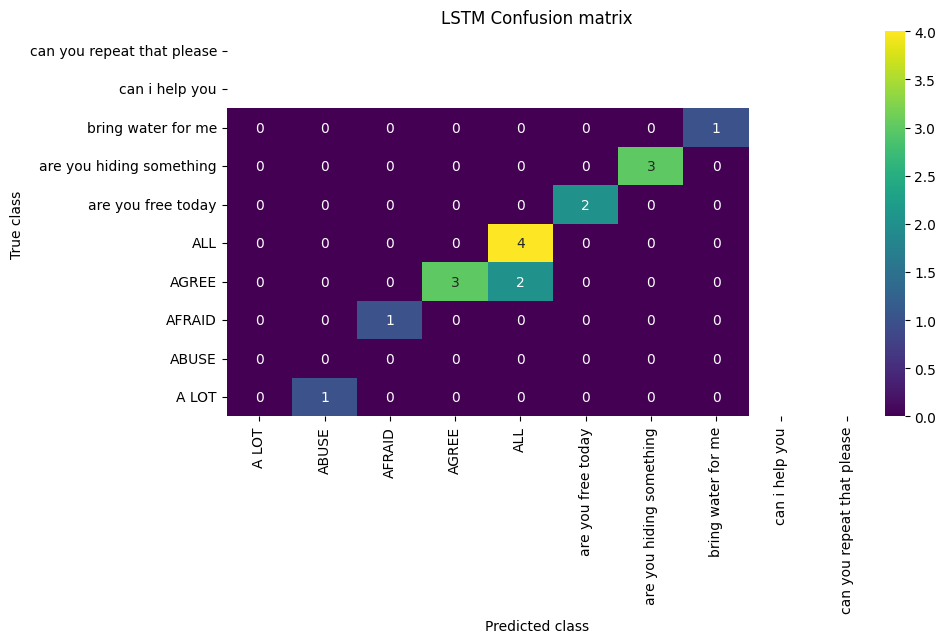

In [11]:
import os

lstm_model = Sequential()
lstm_model.add(Convolution2D(32, (1, 1), input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation="relu"))
lstm_model.add(MaxPooling2D(pool_size=(1, 1)))
lstm_model.add(Convolution2D(32, (1, 1), activation="relu"))
lstm_model.add(MaxPooling2D(pool_size=(1, 1)))
lstm_model.add(Flatten())
lstm_model.add(RepeatVector(3))
lstm_model.add(Bidirectional(LSTM(32, activation="relu")))
lstm_model.add(Dense(units=64))
lstm_model.add(Dense(units=y_train.shape[1], activation="softmax"))
lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

if os.path.exists("model/lstm_weights.h5"):
    lstm_model.load_weights("model/lstm_weights.h5")
    print("LSTM Model Loaded")
else:
    model_check_point = ModelCheckpoint(filepath="model/lstm_weights.h5", verbose=1, save_best_only=True, save_weights_only=True)
    hist = lstm_model.fit(X_train, y_train, batch_size=8, epochs=100,
                          validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open("model/lstm_hist.pckl", "wb")
    pickle.dump(hist.history, f)
    f.close()
    print("Model trained and saved")

predict = lstm_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
calculateMetrics("LSTM", predict, y_test1)

In [12]:
#window based webcam coding
from tkinter import messagebox
from tkinter import *
from tkinter import simpledialog
import tkinter
from tkinter import filedialog
from tkinter.filedialog import askopenfilename
import timeit

In [13]:
#in above screen defining function to detect sign and gesture from webcan
def gesturefromWebcam():
    global model, sc, min_detection_confidence, min_tracking_confidence, labels
    camera = cv2.VideoCapture(0)
    yolo_predict = False
    while(True):
        (grabbed, frame) = camera.read()
        if frame is not None:
            if yolo_predict == False:
                yolo_img, label = detectSign(frame.copy())#call yolo to get sign
                yolo_predict = True
            if yolo_predict == True: #if sign detected with true then apply lstm to get gesture
                frame = cv2.resize(frame, (1000, 800))
                img = cv2.flip(frame, 1)
                debug_image = copy.deepcopy(img)
                results = hands.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                if results.multi_hand_landmarks is not None:
                    for hand_landmarks in results.multi_hand_landmarks:
                        drawingModule.draw_landmarks(img, hand_landmarks, mp_hands.HAND_CONNECTIONS)
                        brect = calc_bounding_rect(debug_image, hand_landmarks)
                        landmark_list = calc_landmark_list(debug_image, hand_landmarks)
                        pre_processed_landmark_list = pre_process_landmark(landmark_list)
                        data = []
                        data.append(pre_processed_landmark_list)
                        data = np.asarray(data)
                        data = sc.transform(data)
                        data = np.reshape(data, (data.shape[0], data.shape[1], 1, 1))
                        predict = lstm_model.predict(data)#apply lstm to get gesture output
                        predict = np.argmax(predict)
                        cv2.putText(yolo_img, 'Gesture = '+labels[predict], (10, 25),  cv2.FONT_HERSHEY_SIMPLEX,0.9, (0, 0, 255), 2)   
                        yolo_predict = False
                else:
                    yolo_img = frame
            else:
                yolo_img = frame
            frame = cv2.resize(yolo_img, (1000, 800))            
            cv2.imshow("Sign Langauge Prediction", frame)
            keypress = cv2.waitKey(1) & 0xFF
            if keypress == ord("q"):
                break
        else:
            break
    camera.release()
    cv2.destroyAllWindows()  

In [14]:
import tkinter as tk
from tkinter import font as tkfont

BG        = "#1a1a2e"
CARD      = "#16213e"
ACCENT    = "#e94560"
BTN_HOVER = "#c73652"
TEXT      = "#eaeaea"
SUBTEXT   = "#9999bb"

root = tk.Tk()
root.title("Indian Sign Language Detector")
root.geometry("600x480")
root.configure(bg=BG)
root.resizable(False, False)

# ── Header bar ────────────────────────────────────────────
header = tk.Frame(root, bg=ACCENT, height=8)
header.pack(fill="x")

# ── Logo / icon area ──────────────────────────────────────
icon_frame = tk.Frame(root, bg=BG)
icon_frame.pack(pady=(30, 0))
tk.Label(icon_frame, text="🤘", font=("Segoe UI Emoji", 56),
         bg=BG).pack()

# ── Title ─────────────────────────────────────────────────
tk.Label(root, text="Indian Sign Language Detector",
         font=("Helvetica", 20, "bold"), bg=BG, fg=TEXT).pack(pady=(10, 4))
tk.Label(root, text="Real-time A–Z detection  |  YOLO11  +  BiLSTM  +  MediaPipe",
         font=("Helvetica", 10), bg=BG, fg=SUBTEXT).pack()

# ── Divider ───────────────────────────────────────────────
tk.Frame(root, bg=CARD, height=2).pack(fill="x", padx=60, pady=20)

# ── Info cards ────────────────────────────────────────────
cards_row = tk.Frame(root, bg=BG)
cards_row.pack(pady=(0, 20))

def make_card(parent, icon, label):
    f = tk.Frame(parent, bg=CARD, padx=18, pady=12)
    f.pack(side="left", padx=8)
    tk.Label(f, text=icon, font=("Segoe UI Emoji", 20), bg=CARD).pack()
    tk.Label(f, text=label, font=("Helvetica", 9), bg=CARD, fg=SUBTEXT).pack()

make_card(cards_row, "📷", "Webcam")
make_card(cards_row, "🧠", "AI Model")
make_card(cards_row, "🤚", "26 Signs")
make_card(cards_row, "⚡", "Real-time")

# ── Start button ──────────────────────────────────────────
btn = tk.Button(
    root,
    text="  ▶   START DETECTION",
    font=("Helvetica", 13, "bold"),
    bg=ACCENT, fg="white",
    activebackground=BTN_HOVER, activeforeground="white",
    bd=0, padx=30, pady=14,
    cursor="hand2",
    command=gesturefromWebcam
)
btn.pack(pady=(0, 12))
btn.bind("<Enter>", lambda e: btn.config(bg=BTN_HOVER))
btn.bind("<Leave>", lambda e: btn.config(bg=ACCENT))

# ── Hint text ─────────────────────────────────────────────
tk.Label(root, text="Press  Q  inside the camera window to stop",
         font=("Helvetica", 9), bg=BG, fg=SUBTEXT).pack()

# ── Bottom accent bar ─────────────────────────────────────
tk.Frame(root, bg=ACCENT, height=4).pack(fill="x", side="bottom")

root.mainloop()



0: 480x640 (no detections), 88.7ms
Speed: 8.5ms preprocess, 88.7ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)
1/1 [==============================] - 0s 19ms/step

0: 480x640 (no detections), 68.9ms
Speed: 1.7ms preprocess, 68.9ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
1/1 [==============================] - 0s 20ms/step

0: 480x640 (no detections), 72.8ms
Speed: 1.3ms preprocess, 72.8ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
1/1 [==============================] - 0s 19ms/step

0: 480x640 (no detections), 72.5ms
Speed: 1.3ms preprocess, 72.5ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
1/1 [==============================] - 0s 20ms/step

0: 480x640 (no detections), 64.8ms
Speed: 1.3ms preprocess, 64.8ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
1/1 [==============================] - 0s 19ms/step

0: 480x640 1 C, 69.8ms
Speed: 1.5ms preprocess, 69.8ms inference, 1.1ms po